# Kunming AI+ · Workshop 4 — Convolutional Neural Networks

In the slides we saw why CNNs suit images and what key pieces do (convolution, feature maps, stride/padding, pooling).

**Today we will:**
1. Load CIFAR-10 (32×32 colour images, 10 classes) using PyTorch `Dataset` and `DataLoader`.
2. Train a classic fully-connected network as a baseline.
3. Build a small CNN and train it.
4. Diagnose training with loss / accuracy curves, then evaluate with a confusion matrix.
5. For fun, we'll end by visualisins the learned filters and the feature maps.

## Part 0 — Setup

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


torch.manual_seed(0); np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


## Part 1 — Image Dataset and Dataloader Generation

CIFAR-10 is 60,000 colour images (50k train + 10k test), each 32×32×3, in 10 classes. We normalise each channel and wrap everything in `DataLoader`s that hand us shuffled mini-batches. Recall from `Practical Workshop 2`, we typically apply random transformations to image data to ensure the model does not learn representations that are orientation/scale/colour dependent. An image of a cat should be classified as cat no matter if the image has been altered.

In [4]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([T.RandomCrop(32, padding=4),
                      T.RandomHorizontalFlip(),
                      T.ToTensor(),
                      T.Normalize(MEAN, STD)])

eval_tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

train_full = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_tf)
val_full   = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=eval_tf)
test_set   = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=eval_tf)

n_val = 5000
train_idx, val_idx = train_test_split(range(len(train_full)),
                                      test_size=n_val,
                                      random_state=0,
                                      stratify=train_full.targets)

train_set = Subset(train_full, train_idx)
val_set   = Subset(val_full,   val_idx)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

classes = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")
print(f"train {len(train_set)} | val {len(val_set)} | test {len(test_set)}")

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
train 45000 | val 5000 | test 10000


Let's plot some samples to understand what sort of data we have.

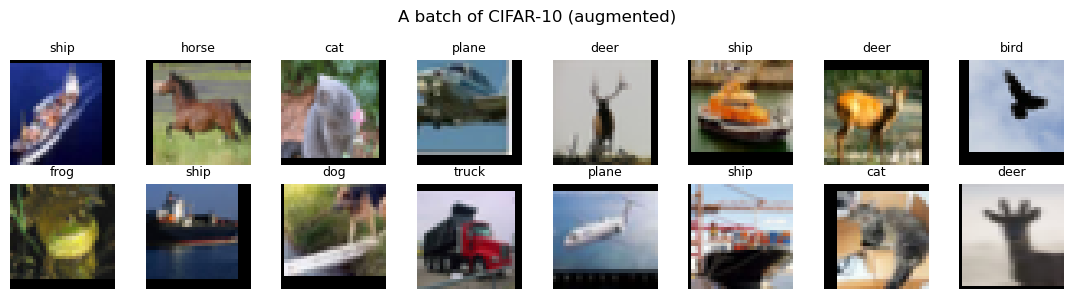

In [5]:
def unnormalise(img):
    img = img.cpu().clone()

    for c in range(3):
        img[c] = img[c] * STD[c] + MEAN[c]
        
    return img.clamp(0, 1).permute(1, 2, 0).numpy()
 
images, labels = next(iter(train_loader))

fig, axs = plt.subplots(2, 8, figsize=(11, 3))

for ax, img, y in zip(axs.flat, images, labels):
    ax.imshow(unnormalise(img)); ax.set_title(classes[y], fontsize=9)
    ax.axis("off")

plt.suptitle("A batch of CIFAR-10 (augmented)"); plt.tight_layout(); plt.show()

## Part 2 — Fully Connected Neural Network Approach

Before building the CNN, let's train a classical fully connected neural network since we already know how to do this. The input to the model will be a flattened version of the image into a 1D vector. The vector is feed through `Linear` layers.

In [6]:
class MLP(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(),
                                 nn.Linear(3*32*32, 256), 
                                 nn.ReLU(),
                                 nn.Linear(256, 128),
                                 nn.ReLU(),
                                 nn.Linear(128, n_classes))
                                 
    def forward(self, x):
        return self.net(x)
 
def count_params(model):
    return sum(p.numel() for p in model.parameters())
 
print("MLP parameters:", f"{count_params(MLP()):,}")

MLP parameters: 820,874


## Part 3 — Convolutional Neural Network Builder

The same idea as the slides. We'll stack `Conv → ReLU → Pool` blocks, then a small dense MLP head. Each block doubles the number of filters and halves the spatial size:

`3×32×32  →  16×16×16  →  32×8×8  →  64×4×4  →  flatten  →  10 scores`

We will use the `nn.Conv2D(in_channels, num_filters, kernel_size, padding, bias)` function to define the convolutional layer.

At the start of the MLP layer, we will run an `AvgPool` operation to average each of the feature maps independently before flattening.

In [ ]:
class CNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),   nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),  # 32 -> 16
            nn.Conv2d(32, 64, 3, padding=1, bias=False),  nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),  # 16 -> 8
            nn.Conv2d(64, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),  # 8  -> 4
        )
        
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1),   # global average pool: (B,128,4,4) -> (B,128,1,1)
                                  nn.Flatten(),
                                  nn.Dropout(0.1),
                                  nn.Linear(128, n_classes))

    def forward(self, x):
        return self.head(self.features(x))

In [8]:
cnn = CNN()
x = torch.randn(1, 3, 32, 32)
print(f"{'input':12s}", tuple(x.shape))
for layer in cnn.features:
    x = layer(x)
    print(f"{layer.__class__.__name__:12s}", tuple(x.shape))
 
print(f"\nCNN parameters: {count_params(cnn):,}")
print(f"MLP parameters: {count_params(MLP()):,}")

input        (1, 3, 32, 32)
Conv2d       (1, 32, 32, 32)
BatchNorm2d  (1, 32, 32, 32)
ReLU         (1, 32, 32, 32)
MaxPool2d    (1, 32, 16, 16)
Conv2d       (1, 64, 16, 16)
BatchNorm2d  (1, 64, 16, 16)
ReLU         (1, 64, 16, 16)
MaxPool2d    (1, 64, 8, 8)
Conv2d       (1, 128, 8, 8)
BatchNorm2d  (1, 128, 8, 8)
ReLU         (1, 128, 8, 8)
MaxPool2d    (1, 128, 4, 4)

CNN parameters: 94,762
MLP parameters: 820,874


The CNN has far FEWER parameters than the MLP as a result of its parameter sharing property.

## Part 4 — CNN Training 

The five-step loop from the earlier sessions trains our model. We use **cross-entropy** loss (the standard choice for multi-class classification, which expects raw logits).

In [ ]:
@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    preds_all, labels_all = [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss_sum += loss_fn(logits, y).item() * X.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item(); total += X.size(0)
        preds_all.append(preds.cpu()); labels_all.append(y.cpu())
    return loss_sum/total, correct/total, torch.cat(preds_all), torch.cat(labels_all)
 

def train(model, epochs=5, lr=1e-3, weight_decay=5e-4):
    model.to(device)

    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)
    opt     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
 
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):
        model.train()
        total, correct, loss_sum = 0, 0, 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)              # 1. forward
            loss = loss_fn(logits, y)    # 2. loss
            opt.zero_grad()                # 5. zero the old gradients
            loss.backward()                # 3. backward
            opt.step()                     # 4. update parameters
            loss_sum += loss.item() * X.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += X.size(0)
 
        sched.step()   # reduce the learning rate once per epoch to help training
        val_loss, val_acc, _, _ = evaluate(model, val_loader, loss_fn)
        history["train_loss"].append(loss_sum/total)
        history["train_acc"].append(correct/total)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"epoch {epoch+1:2d} | train acc {correct/total:.3f} | val acc {val_acc:.3f} | lr {sched.get_last_lr()[0]:.2e}")
    return history

We train the MLP baseline and the CNN on exactly the same data, so the comparison is fair.

In [10]:
EPOCHS = 50
 
print("Training the MLP baseline...")
mlp = MLP()
hist_mlp = train(mlp, epochs=EPOCHS, lr=1e-3)
 
print("\nTraining the CNN...")
cnn = CNN()
hist_cnn = train(cnn, epochs=EPOCHS, lr=1e-3)

Training the MLP baseline...


epoch  1 | train acc 0.344 | val acc 0.404 | lr 9.99e-04
epoch  2 | train acc 0.404 | val acc 0.422 | lr 9.96e-04
epoch  3 | train acc 0.430 | val acc 0.436 | lr 9.91e-04
epoch  4 | train acc 0.444 | val acc 0.438 | lr 9.84e-04
epoch  5 | train acc 0.458 | val acc 0.463 | lr 9.76e-04
epoch  6 | train acc 0.469 | val acc 0.471 | lr 9.65e-04
epoch  7 | train acc 0.478 | val acc 0.449 | lr 9.52e-04
epoch  8 | train acc 0.484 | val acc 0.473 | lr 9.38e-04
epoch  9 | train acc 0.493 | val acc 0.454 | lr 9.22e-04
epoch 10 | train acc 0.499 | val acc 0.445 | lr 9.05e-04
epoch 11 | train acc 0.500 | val acc 0.467 | lr 8.85e-04
epoch 12 | train acc 0.504 | val acc 0.469 | lr 8.64e-04
epoch 13 | train acc 0.509 | val acc 0.477 | lr 8.42e-04
epoch 14 | train acc 0.512 | val acc 0.491 | lr 8.19e-04
epoch 15 | train acc 0.519 | val acc 0.482 | lr 7.94e-04
epoch 16 | train acc 0.523 | val acc 0.473 | lr 7.68e-04
epoch 17 | train acc 0.526 | val acc 0.485 | lr 7.41e-04
epoch 18 | train acc 0.528 | va

## Part 5 — Evaluate Training and Diagnose any Pathologies

Let's evaluate the training curves to see if there are any pathologies using our knowledge from workshop 3.

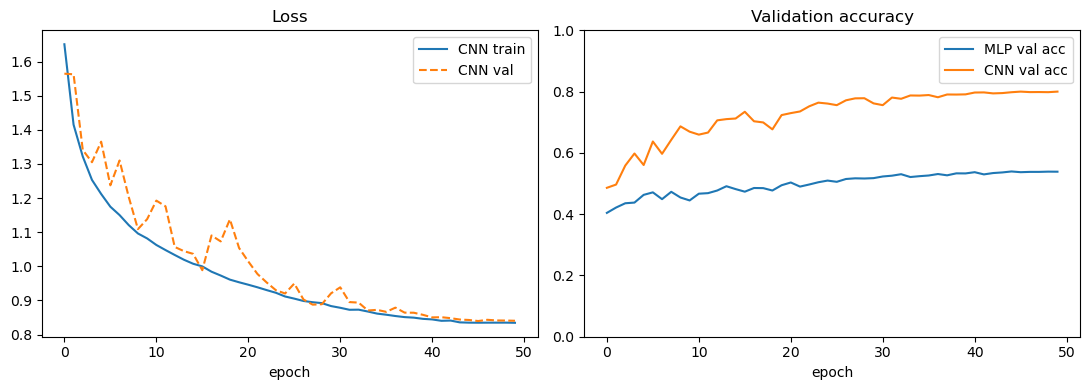

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
 
axs[0].plot(hist_cnn["train_loss"], label="CNN train")
axs[0].plot(hist_cnn["val_loss"],   label="CNN val", linestyle="--")
axs[0].set_title("Loss"); axs[0].set_xlabel("epoch"); axs[0].legend()
 
axs[1].plot(hist_mlp["val_acc"], label="MLP val acc")
axs[1].plot(hist_cnn["val_acc"], label="CNN val acc")
axs[1].set_title("Validation accuracy"); axs[1].set_xlabel("epoch")
axs[1].set_ylim(0, 1); axs[1].legend()
 
plt.tight_layout(); plt.show()

Let's now evaluate the model on the test set to estimate real-world performance.

In [12]:
loss_fn = nn.CrossEntropyLoss()
_, mlp_acc, _, _           = evaluate(mlp, test_loader, loss_fn)
_, cnn_acc, preds, labels  = evaluate(cnn, test_loader, loss_fn)
print(f"MLP test accuracy: {mlp_acc:.3f}")
print(f"CNN test accuracy: {cnn_acc:.3f}")

MLP test accuracy: 0.537
CNN test accuracy: 0.797


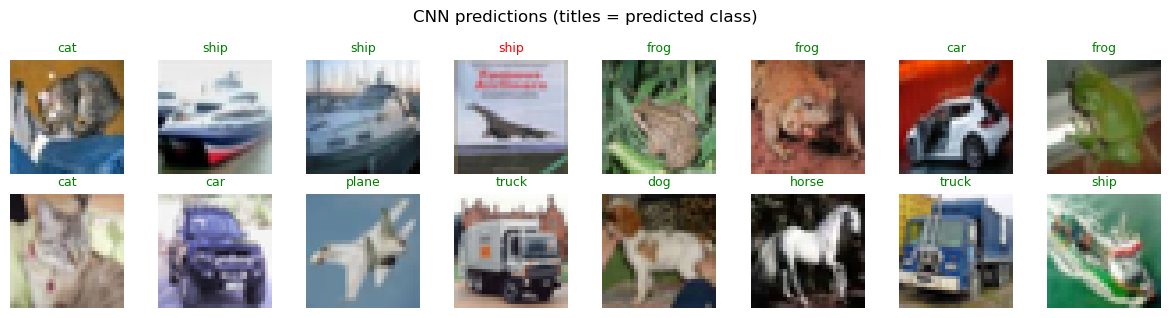

In [13]:
# A few test predictions — green = correct, red = wrong.
images, ys = next(iter(test_loader))

with torch.no_grad():
    p = cnn(images.to(device)).argmax(1).cpu()

fig, axs = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, true, pred in zip(axs.flat, images, ys, p):
    ax.imshow(unnormalise(img)); ax.axis("off")
    ok = (true == pred)
    ax.set_title(f"{classes[pred]}", color=("green" if ok else "red"), fontsize=9)

plt.suptitle("CNN predictions (titles = predicted class)")
plt.tight_layout()
plt.show()

## Part 6 — Looking into The Feature Maps (Just for fun)

The first convolutional layer has 16 filters of shape `3×3×3`. Because they act directly on
the RGB input we can view each one as a tiny colour patch. Many become simple edge / colour detectors.

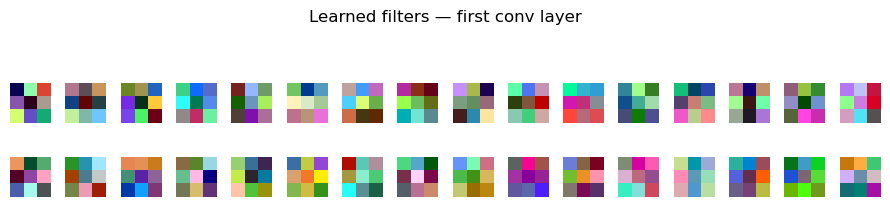

In [14]:
def show_filters(weight):
    w = weight.detach().cpu()
    n = w.shape[0]

    fig, axs = plt.subplots(2, n // 2, figsize=(9, 2.4))

    for i, ax in enumerate(axs.flat):
        f = w[i]
        f = (f - f.min()) / (f.max() - f.min() + 1e-8)   # normalise to [0,1] for display
        ax.imshow(f.permute(1, 2, 0).numpy()); ax.axis("off")
        
    plt.suptitle("Learned filters — first conv layer")
    plt.tight_layout()
    plt.show()

show_filters(cnn.features[0].weight)

Now, let's observe the action of the feature maps. We pass one image through the network and watch the activations. As you can see, early blocks keep fine detail while deeper blocks become coarser and more abstract.

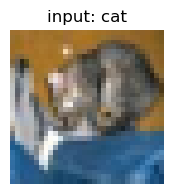

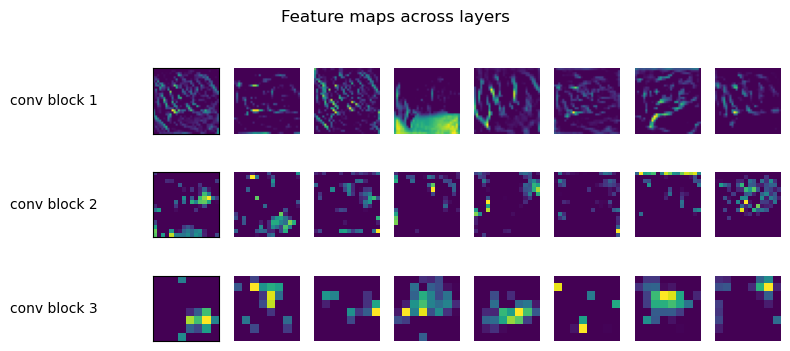

In [ ]:
def feature_maps(model, image, n_show=8):
    model.eval()
    acts, x = [], image.to(device)
    with torch.no_grad():
        for layer in model.features:
            x = layer(x)
            if isinstance(layer, nn.ReLU): 
                acts.append((f"conv block {len(acts)+1}", x.clone()))

    fig, axs = plt.subplots(len(acts), n_show, figsize=(n_show, 1.25 * len(acts)))
    
    for r, (name, a) in enumerate(acts):
        for c in range(n_show):
            axs[r, c].imshow(a[0, c].cpu(), cmap="viridis"); axs[r, c].axis("off")

        axs[r, 0].set_ylabel(name, rotation=0, ha="right", va="center", labelpad=40)
        axs[r, 0].axis("on")
        axs[r, 0].set_xticks([])
        axs[r, 0].set_yticks([])

    plt.suptitle("Feature maps across layers")
    plt.tight_layout()
    plt.show()

# show the original image, then its feature maps
img, lbl = test_set[0]
plt.figure(figsize=(2, 2)); plt.imshow(unnormalise(img))
plt.title(f"input: {classes[lbl]}"); plt.axis("off"); plt.show()

feature_maps(cnn, img.unsqueeze(0))

### Next: Practical Workshop 4 — Sklearn

PCA for dimensionality reduction, random forests for feature importance, pipelines, classical models.